# Marketing ROI Optimisation — Exploratory Data Analysis

**Project**: EFREI M1 Data Engineering — RNCP40875  
**Dataset**: `data/marketing_labelled.csv`  
**Target**: `Sales` (regression) / `perf_class` (classification: Low / Medium / High)

This notebook mirrors the dashboard **Overview** (`/stats`) and **Analytics** (`/analytics`) pages so EDA results match what users see in the Next.js frontend.

---
## Contents
1. Setup & Data Loading  
2. Dataset Overview & KPIs  
3. Overview Charts — sales distribution, budget mix, influencer, correlation, efficiency, benchmarks  
4. Feature Distributions (25 bins)  
5. Statistical Summary Table  
6. Outlier Analysis (IQR method)  
7. Scatter Analysis — TV & Radio vs Sales  
8. Sales by Influencer Tier  
9. Performance Class Distribution  
10. Pairwise Correlations  
11. Key Findings

In [3]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_data, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET_REG, TARGET_CLF

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

# Colours aligned with dashboard-next (Overview + Analytics pages)
CH = {"TV": "#3b82f6", "Radio": "#8b5cf6", "Social Media": "#06b6d4"}
FEAT_COLOR = {**CH, "Sales": "#10b981"}
INF_COLOR = {"Mega": "#6366f1", "Macro": "#8b5cf6", "Micro": "#06b6d4", "Nano": "#f59e0b"}
CLASS_COLOR = {"Low": "#ef4444", "Medium": "#f59e0b", "High": "#10b981"}
INF_ORDER = ["Mega", "Macro", "Micro", "Nano"]
FEATURES_ORDER = ["TV", "Radio", "Social Media", "Sales"]

df = load_data()
df["Total_Budget"] = df[NUMERIC_FEATURES].sum(axis=1)
df["ROI"] = df[TARGET_REG] / df["Total_Budget"]

sales_q33 = df[TARGET_REG].quantile(1 / 3)
sales_q66 = df[TARGET_REG].quantile(2 / 3)

print(f"Shape: {df.shape}")
df.head()

Shape: (4572, 8)


,TV,Radio,Social Media,Influencer,Sales,perf_class,Total_Budget,ROI
0,16.0,6.566231,2.907983,Mega,54.732757,Low,25.474214,2.148555
1,13.0,9.237765,2.409567,Mega,46.677897,Low,24.647332,1.893832
2,41.0,15.886446,2.913410,Mega,150.177829,Medium,59.799856,2.511341
3,83.0,30.020028,6.922304,Mega,298.246340,High,119.942332,2.486581
4,15.0,8.437408,1.405998,Micro,56.594181,Low,24.843406,2.278036


## 2. Dataset Overview & KPIs

Same KPIs as the dashboard Overview page (`GET /stats`).

In [4]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Descriptive statistics ===")
display(df.describe().round(2))

correlations = {col: round(float(df[col].corr(df[TARGET_REG])), 4) for col in NUMERIC_FEATURES}
budget_breakdown = {col: round(float(df[col].mean()), 2) for col in NUMERIC_FEATURES}
total_budget_avg = round(float(df["Total_Budget"].mean()), 2)

print("\n=== Dashboard KPIs ===")
print(f"Total campaigns : {len(df):,}")
print(f"Avg sales       : {df[TARGET_REG].mean():.2f} M")
print(f"Avg ROI         : {df['ROI'].mean():.4f}")
print(f"Avg total budget: {total_budget_avg:.2f} M")
print(f"Best channel    : {max(correlations, key=correlations.get)} (r={max(correlations.values()):.4f})")
print(f"Sales Q33 / Q66 : {sales_q33:.2f} / {sales_q66:.2f} M")

=== dtypes ===
TV              float64
Radio           float64
Social Media    float64
Influencer          str
Sales           float64
perf_class          str
Total_Budget    float64
ROI             float64
dtype: object

=== Missing values ===
TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
perf_class       0
Total_Budget     0
ROI              6
dtype: int64

=== Descriptive statistics ===


,TV,Radio,Social Media,Sales,Total_Budget,ROI
count,4562.00,4568.00,4566.00,4566.00,4572.00,4566.00
mean,54.07,18.16,3.32,192.47,75.41,2.57
std,26.13,9.68,2.21,93.13,36.19,0.61
min,10.00,0.00,0.00,31.20,1.68,1.27
25%,32.00,10.53,1.53,112.32,44.18,2.41
50%,53.00,17.86,3.06,189.23,74.05,2.55
75%,77.00,25.65,4.81,272.51,106.65,2.70
max,100.00,48.87,13.98,364.08,156.16,33.59



=== Dashboard KPIs ===
Total campaigns : 4,572
Avg sales       : 192.47 M
Avg ROI         : 2.5674
Avg total budget: 75.41 M
Best channel    : TV (r=0.9995)
Sales Q33 / Q66 : 138.08 / 244.24 M


## 3. Overview Charts

Matches the Overview dashboard: sales distribution, budget mix, influencer performance, channel correlation, revenue efficiency, and performance benchmarks.

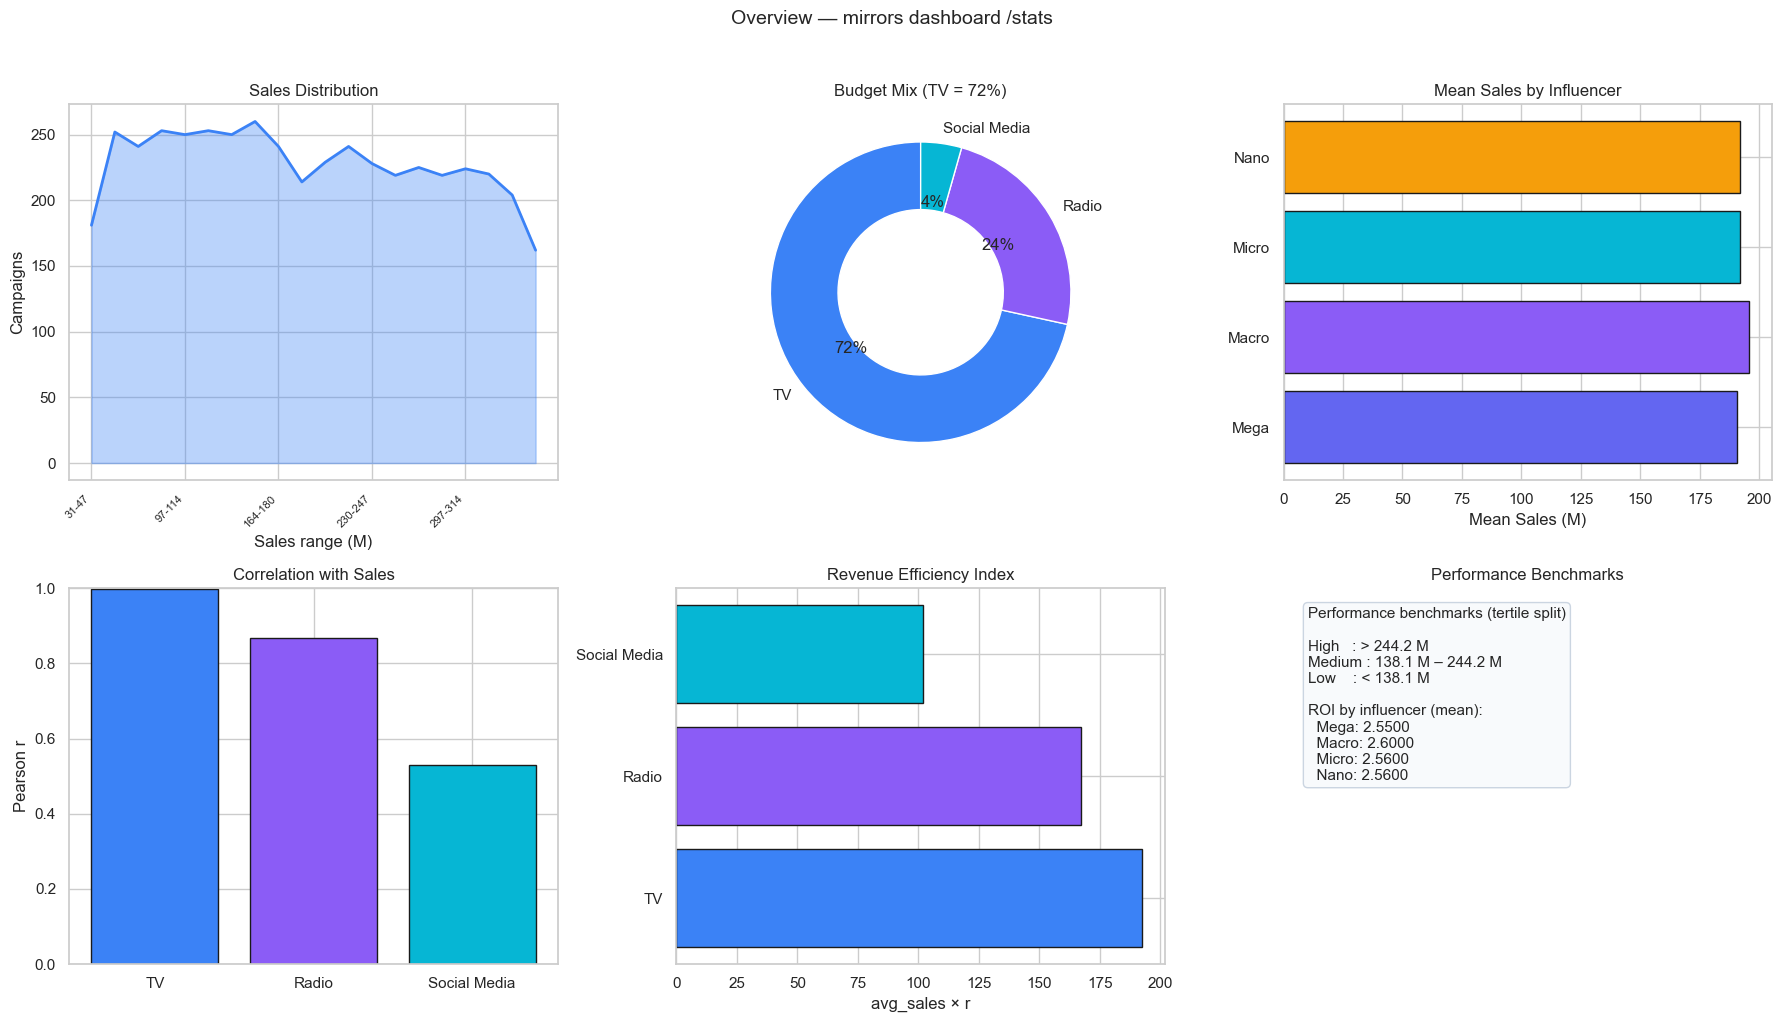

Channel correlations with Sales:
TV              0.9995
Radio           0.8691
Social Media    0.5289


In [5]:
counts, edges = np.histogram(df[TARGET_REG].dropna(), bins=20)
sales_dist = pd.DataFrame({
    "range": [f"{int(edges[i])}-{int(edges[i+1])}" for i in range(len(counts))],
    "count": counts,
})

by_inf = df.groupby("Influencer")[[TARGET_REG, "ROI"]].mean().round(2)
budget_df = pd.Series(budget_breakdown)
correl_df = pd.Series(correlations)
efficiency = correl_df * df[TARGET_REG].mean()
total_budget_channels = budget_df.sum()
tv_budget_pct = round(budget_df["TV"] / total_budget_channels * 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sales distribution (area-style bar)
axes[0, 0].fill_between(range(len(sales_dist)), sales_dist["count"], alpha=0.35, color="#3b82f6")
axes[0, 0].plot(sales_dist["count"], color="#3b82f6", linewidth=2)
axes[0, 0].set_title("Sales Distribution")
axes[0, 0].set_xlabel("Sales range (M)")
axes[0, 0].set_ylabel("Campaigns")
axes[0, 0].set_xticks(range(0, len(sales_dist), 4))
axes[0, 0].set_xticklabels(sales_dist["range"].iloc[::4], rotation=45, ha="right", fontsize=8)

# Budget mix donut
axes[0, 1].pie(
    budget_df.values, labels=budget_df.index, autopct="%1.0f%%",
    colors=[CH[k] for k in budget_df.index], startangle=90,
    wedgeprops=dict(width=0.45, edgecolor="white"),
)
axes[0, 1].set_title(f"Budget Mix (TV = {tv_budget_pct}%)")

# Mean sales by influencer

mean_sales = by_inf[TARGET_REG].reindex(INF_ORDER)
axes[0, 2].barh(mean_sales.index, mean_sales.values,
                color=[INF_COLOR[i] for i in mean_sales.index], edgecolor="k")
axes[0, 2].set_title("Mean Sales by Influencer")
axes[0, 2].set_xlabel("Mean Sales (M)")

# Channel correlation with Sales
axes[1, 0].bar(correl_df.index, correl_df.values,
               color=[CH[k] for k in correl_df.index], edgecolor="k")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title("Correlation with Sales")
axes[1, 0].set_ylabel("Pearson r")

# Revenue efficiency index (avg_sales × correlation)
axes[1, 1].barh(efficiency.index, efficiency.values,
                color=[CH[k] for k in efficiency.index], edgecolor="k")
axes[1, 1].set_title("Revenue Efficiency Index")
axes[1, 1].set_xlabel("avg_sales × r")

# Performance benchmarks (quantile tiers)
axes[1, 2].axis("off")
benchmark_text = (
    f"Performance benchmarks (tertile split)\n\n"
    f"High   : > {sales_q66:.1f} M\n"
    f"Medium : {sales_q33:.1f} M – {sales_q66:.1f} M\n"
    f"Low    : < {sales_q33:.1f} M\n\n"
    f"ROI by influencer (mean):\n"
    + "\n".join(f"  {k}: {v:.4f}" for k, v in by_inf["ROI"].reindex(INF_ORDER).items())
)
axes[1, 2].text(0.05, 0.95, benchmark_text, va="top", fontsize=11,
                bbox=dict(boxstyle="round", facecolor="#f8fafc", edgecolor="#cbd5e1"))
axes[1, 2].set_title("Performance Benchmarks")

plt.suptitle("Overview — mirrors dashboard /stats", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("Channel correlations with Sales:")
print(correl_df.to_string())

## 4. Feature Distributions

25-bin histograms with mean / median reference lines — same logic as `GET /analytics`.

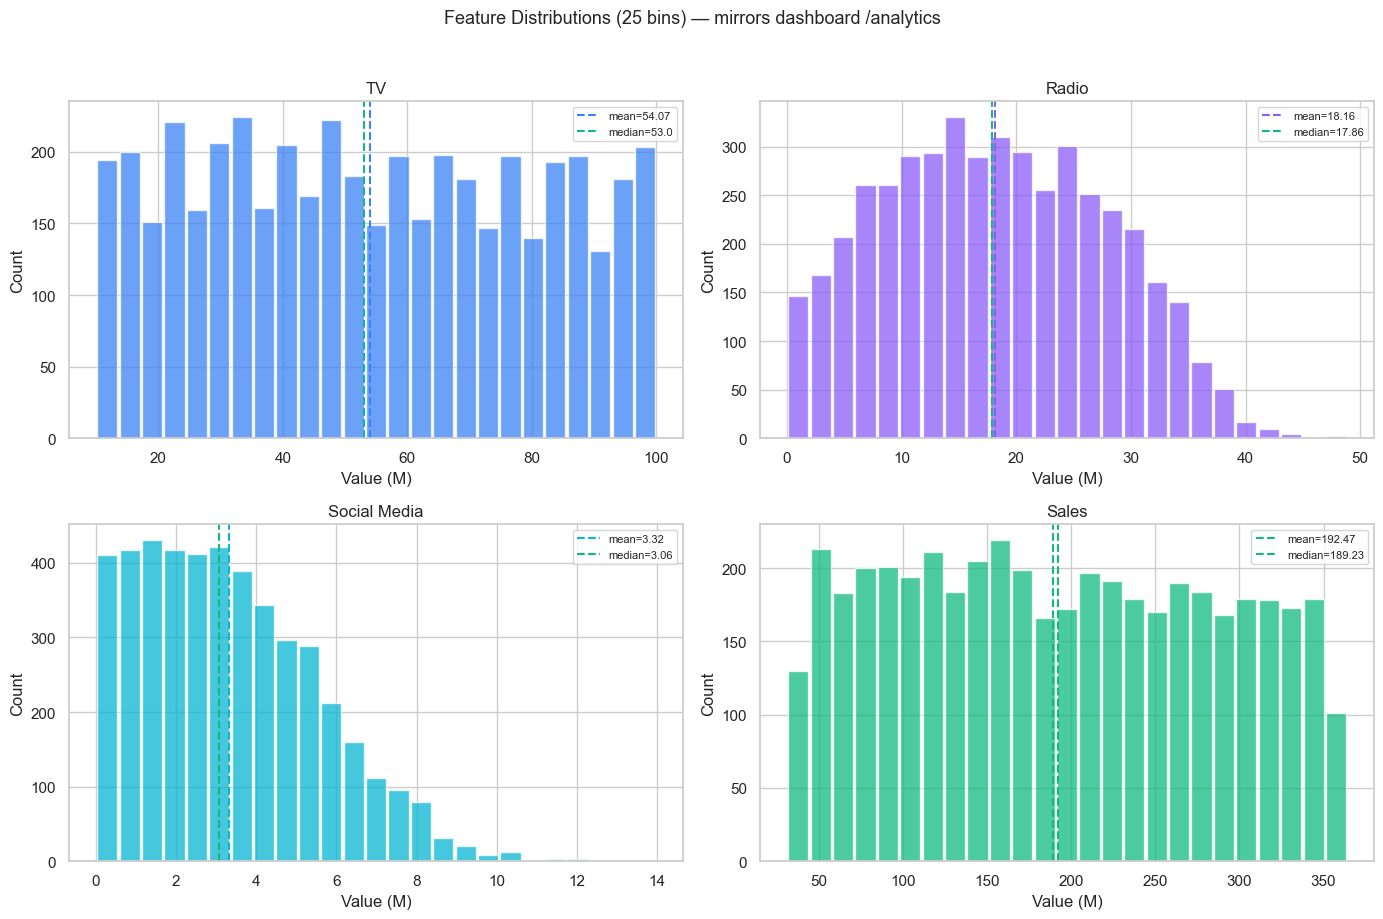

In [6]:
def compute_feature_stats(series: pd.Series) -> dict:
    """Mirror api/main.py _analytics feature_stats logic."""
    s = series.dropna()
    q1, q3 = float(s.quantile(0.25)), float(s.quantile(0.75))
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]
    return {
        "mean": round(float(s.mean()), 2),
        "median": round(float(s.median()), 2),
        "std": round(float(s.std()), 2),
        "min": round(float(s.min()), 2),
        "max": round(float(s.max()), 2),
        "q1": round(q1, 2),
        "q3": round(q3, 2),
        "iqr": round(iqr, 2),
        "skewness": round(float(s.skew()), 4),
        "kurtosis": round(float(s.kurt()), 4),
        "outlier_count": int(len(outliers)),
        "outlier_pct": round(len(outliers) / len(s) * 100, 2),
        "whisker_low": round(max(float(s.min()), lower), 2),
        "whisker_high": round(min(float(s.max()), upper), 2),
    }


feat_stats = {col: compute_feature_stats(df[col]) for col in FEATURES_ORDER}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, col in zip(axes, FEATURES_ORDER):
    s = df[col].dropna()
    counts, edges = np.histogram(s, bins=25)
    midpoints = (edges[:-1] + edges[1:]) / 2
    stat = feat_stats[col]
    color = FEAT_COLOR[col]

    ax.bar(midpoints, counts, width=(edges[1] - edges[0]) * 0.9,
           color=color, alpha=0.75, edgecolor="white")
    ax.axvline(stat["mean"], color=color, linestyle="--", linewidth=1.5, label=f"mean={stat['mean']}")
    ax.axvline(stat["median"], color="#10b981", linestyle="--", linewidth=1.5, label=f"median={stat['median']}")
    ax.set_title(col)
    ax.set_xlabel("Value (M)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions (25 bins) — mirrors dashboard /analytics", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Statistical Summary Table

Same columns as the Analytics page summary table.

In [7]:
summary_rows = []
for col in FEATURES_ORDER:
    s = feat_stats[col]
    summary_rows.append({
        "Feature": col,
        "Mean": s["mean"], "Median": s["median"], "Std": s["std"],
        "Min": s["min"], "Q1": s["q1"], "Q3": s["q3"], "Max": s["max"],
        "IQR": s["iqr"], "Skewness": s["skewness"],
        "Outliers": f"{s['outlier_count']} ({s['outlier_pct']}%)",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Feature")
display(summary_df)

total_outliers = sum(feat_stats[c]["outlier_count"] for c in FEATURES_ORDER)
print(f"\nTotal outliers (IQR method): {total_outliers}")

,Mean,Median,Std,Min,Q1,Q3,Max,IQR,Skewness,Outliers
Feature,,,,,,,,,,
TV,54.07,53.00,26.13,10.0,32.00,77.00,100.00,45.00,0.0692,0 (0.0%)
Radio,18.16,17.86,9.68,0.0,10.53,25.65,48.87,15.12,0.1432,1 (0.02%)
Social Media,3.32,3.06,2.21,0.0,1.53,4.81,13.98,3.28,0.6449,28 (0.61%)
Sales,192.47,189.23,93.13,31.2,112.32,272.51,364.08,160.19,0.0695,0 (0.0%)



Total outliers (IQR method): 29


## 6. Outlier Analysis (IQR)

Whisker bounds and outlier counts per feature — same IQR rule as the API.

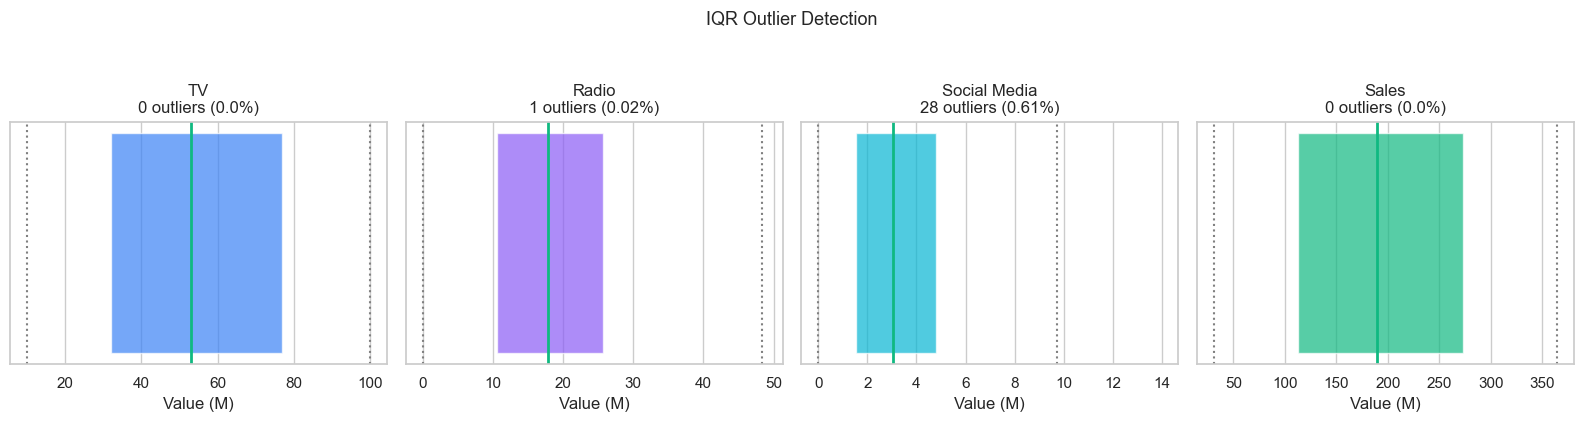

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, FEATURES_ORDER):
    s = feat_stats[col]
    color = FEAT_COLOR[col]
    span = s["max"] - s["min"] or 1

    ax.barh([0], [s["iqr"]], left=s["q1"], height=0.4, color=color, alpha=0.7)
    ax.axvline(s["median"], color="#10b981", linewidth=2)
    ax.axvline(s["whisker_low"], color="gray", linestyle=":")
    ax.axvline(s["whisker_high"], color="gray", linestyle=":")
    ax.set_xlim(s["min"] - span * 0.05, s["max"] + span * 0.05)
    ax.set_yticks([])
    ax.set_title(f"{col}\n{s['outlier_count']} outliers ({s['outlier_pct']}%)")
    ax.set_xlabel("Value (M)")

plt.suptitle("IQR Outlier Detection", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

if total_outliers == 0:
    print("No IQR outliers detected — dataset is clean (matches dashboard message).")

## 7. Scatter Analysis — TV & Radio vs Sales

500-point random sample (`random_state=42`), coloured by influencer tier — same as the dashboard scatter panels.

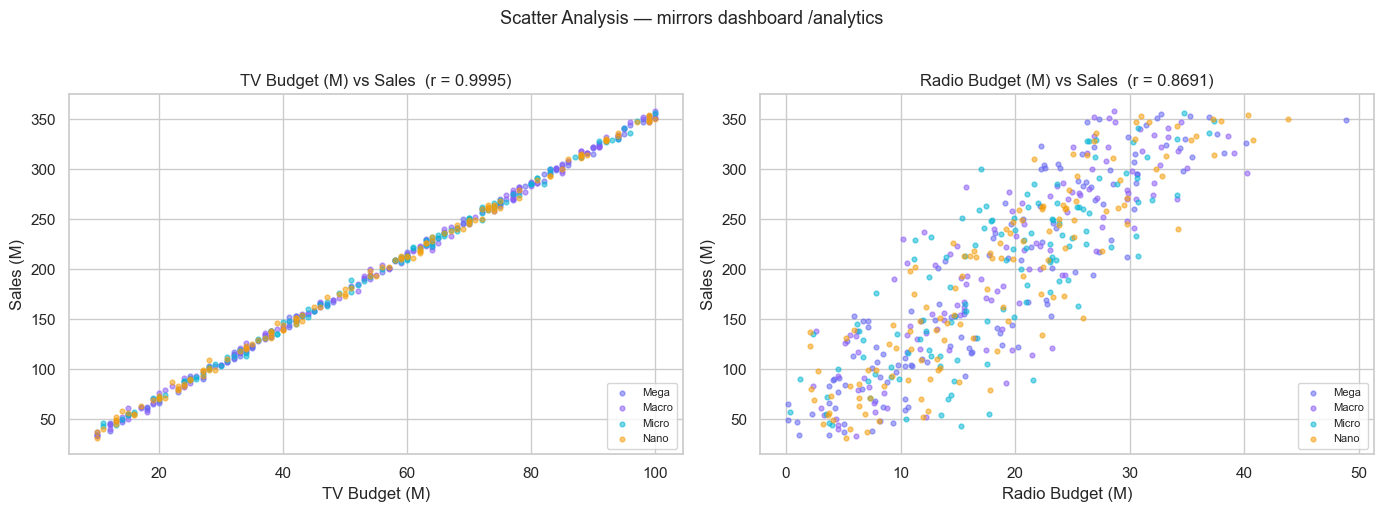

In [9]:
samp = df.sample(min(500, len(df)), random_state=42)

pairwise = {}
for i, c1 in enumerate(FEATURES_ORDER):
    for j, c2 in enumerate(FEATURES_ORDER):
        if i < j:
            pairwise[f"{c1}|{c2}"] = round(float(df[c1].corr(df[c2])), 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, x_col, x_label in zip(
    axes,
    ["TV", "Radio"],
    ["TV Budget (M)", "Radio Budget (M)"],
):
    for inf in INF_ORDER:
        sub = samp[samp["Influencer"] == inf]
        mask = sub[x_col] > 0  # exclude zero-budget campaigns (same as frontend)
        ax.scatter(sub.loc[mask, x_col], sub.loc[mask, TARGET_REG],
                   alpha=0.55, s=12, color=INF_COLOR[inf], label=inf)
    r = pairwise[f"{x_col}|Sales"]
    ax.set_xlabel(x_label)
    ax.set_ylabel("Sales (M)")
    ax.set_title(f"{x_label} vs Sales  (r = {r:.4f})")
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Scatter Analysis — mirrors dashboard /analytics", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Sales by Influencer Tier

Box plot + detailed box statistics table (same metrics as `sales_by_influencer_box` in the API).

C:\Users\Adrien Duval\AppData\Local\Temp\ipykernel_2896\2918798503.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Influencer", y=TARGET_REG, order=INF_ORDER,


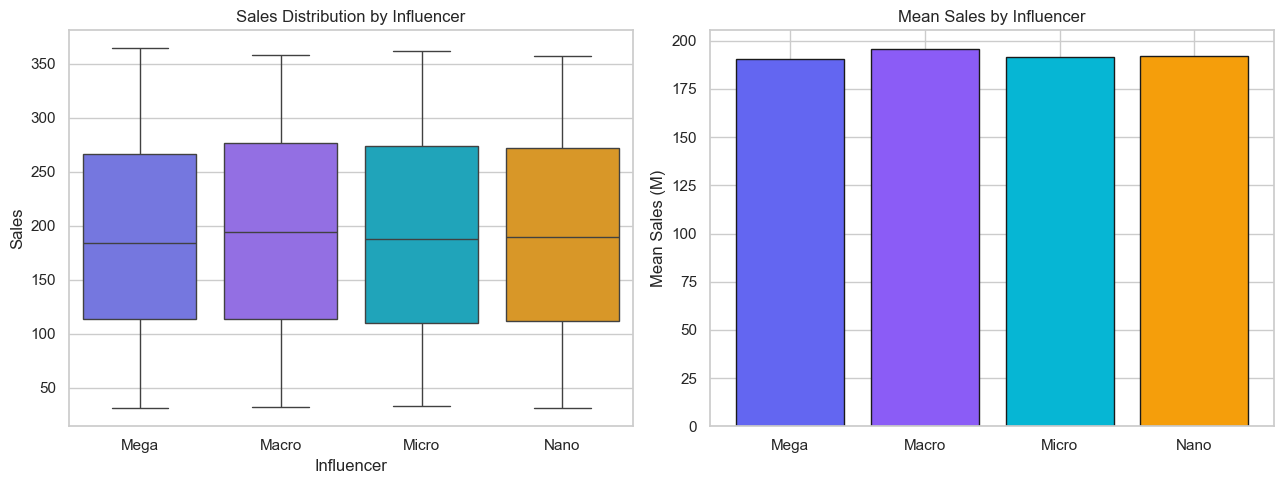

Box statistics by influencer tier:


,min,q1,median,mean,q3,max,std,count
Mega,31.40,113.41,184.17,190.59,266.03,364.08,92.31,1156.0
Macro,32.57,113.68,194.23,195.61,276.40,358.42,92.57,1121.0
Micro,33.72,110.26,187.95,191.81,274.12,362.04,94.30,1152.0
Nano,31.20,111.83,189.66,191.93,271.74,357.12,93.38,1137.0


In [10]:
sales_by_inf = {}
for inf, grp in df.groupby("Influencer"):
    s = grp[TARGET_REG].dropna()
    q1, q3 = float(s.quantile(0.25)), float(s.quantile(0.75))
    iqri = q3 - q1
    sales_by_inf[str(inf)] = {
        "min": round(float(s.min()), 2),
        "q1": round(q1, 2),
        "median": round(float(s.median()), 2),
        "mean": round(float(s.mean()), 2),
        "q3": round(q3, 2),
        "max": round(float(s.max()), 2),
        "std": round(float(s.std()), 2),
        "count": int(len(s)),
    }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Influencer", y=TARGET_REG, order=INF_ORDER,
            palette=[INF_COLOR[i] for i in INF_ORDER], ax=axes[0])
axes[0].set_title("Sales Distribution by Influencer")

mean_sales = df.groupby("Influencer")[TARGET_REG].mean().reindex(INF_ORDER)
axes[1].bar(mean_sales.index, mean_sales.values,
            color=[INF_COLOR[i] for i in mean_sales.index], edgecolor="k")
axes[1].set_title("Mean Sales by Influencer")
axes[1].set_ylabel("Mean Sales (M)")

plt.tight_layout()
plt.show()

box_df = pd.DataFrame(sales_by_inf).T.reindex(INF_ORDER)
print("Box statistics by influencer tier:")
display(box_df)

## 9. Performance Class Distribution

Quantile-based `perf_class` labels (Low / Medium / High) — same pie chart as the dashboard.

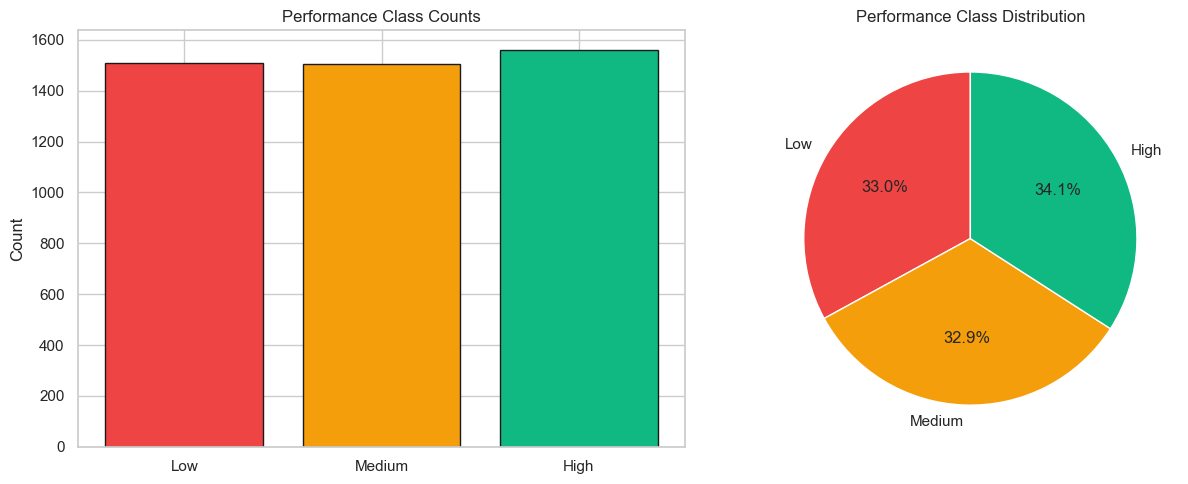


Class distribution:
perf_class
Low       1507
Medium    1506
High      1559

Thresholds: Low < 138.1M | Medium 138.1–244.2M | High > 244.2M


In [11]:
class_order = ["Low", "Medium", "High"]
counts = df[TARGET_CLF].value_counts().reindex(class_order)
colors = [CLASS_COLOR[c] for c in class_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(counts.index, counts.values, color=colors, edgecolor="k")
axes[0].set_title("Performance Class Counts")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[1].set_title("Performance Class Distribution")

plt.tight_layout()
plt.show()

print("\nClass distribution:")
print(counts.to_string())
print(f"\nThresholds: Low < {sales_q33:.1f}M | Medium {sales_q33:.1f}–{sales_q66:.1f}M | High > {sales_q66:.1f}M")

## 10. Correlation Matrix — TV · Radio · Social Media → Sales

Full annotated heatmap, channel-vs-Sales bar chart, and scatter plots with regression lines.

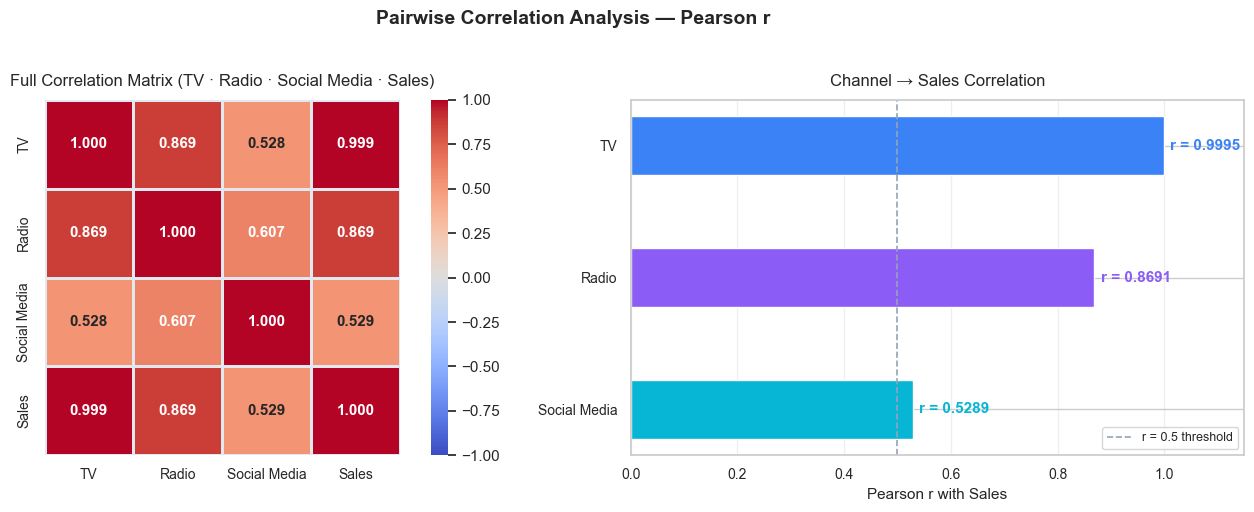

Pairwise correlations (API format):
  Radio|Sales: 0.8691
  Radio|Social Media: 0.6075
  Social Media|Sales: 0.5289
  TV|Radio: 0.8695
  TV|Sales: 0.9995
  TV|Social Media: 0.5282

Correlation with Sales (strongest → weakest):
  TV             : r = 0.9995  (Strong)
  Radio          : r = 0.8691  (Strong)
  Social Media   : r = 0.5289  (Moderate)


In [12]:
corr = df[FEATURES_ORDER].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: full annotated heatmap ──────────────────────────────────────────────
sns.heatmap(
    corr, annot=True, fmt=".3f", cmap="coolwarm",
    ax=axes[0], vmin=-1, vmax=1, square=True,
    linewidths=0.8, linecolor="#e2e8f0",
    annot_kws={"size": 11, "weight": "bold"},
)
axes[0].set_title("Full Correlation Matrix (TV · Radio · Social Media · Sales)", fontsize=12, pad=10)
axes[0].tick_params(labelsize=10)

# ── Right: correlation with Sales as horizontal bar chart ─────────────────────
sales_corr = corr["Sales"].drop("Sales").sort_values(ascending=True)
bar_colors = [FEAT_COLOR.get(c, "#64748b") for c in sales_corr.index]
bars = axes[1].barh(sales_corr.index, sales_corr.values,
                    color=bar_colors, height=0.45, edgecolor="white")
for bar, (col, val) in zip(bars, sales_corr.items()):
    axes[1].text(val + 0.012, bar.get_y() + bar.get_height() / 2,
                 f"r = {val:.4f}", va="center", fontsize=11,
                 fontweight="bold", color=FEAT_COLOR.get(col, "#0f172a"))
axes[1].set_xlim(0, 1.15)
axes[1].set_xlabel("Pearson r with Sales", fontsize=11)
axes[1].set_title("Channel → Sales Correlation", fontsize=12, pad=10)
axes[1].axvline(0.5, color="#94a3b8", linestyle="--", linewidth=1.2, label="r = 0.5 threshold")
axes[1].legend(fontsize=9)
axes[1].tick_params(labelsize=10)
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Pairwise Correlation Analysis — Pearson r", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Pairwise correlations (API format):")
for key, val in sorted(pairwise.items()):
    print(f"  {key}: {val}")

print("\nCorrelation with Sales (strongest → weakest):")
for col, r in sales_corr.sort_values(ascending=False).items():
    strength = "Strong" if abs(r) > 0.7 else "Moderate" if abs(r) > 0.4 else "Weak"
    print(f"  {col:15s}: r = {r:.4f}  ({strength})")


LinAlgError: SVD did not converge in Linear Least Squares

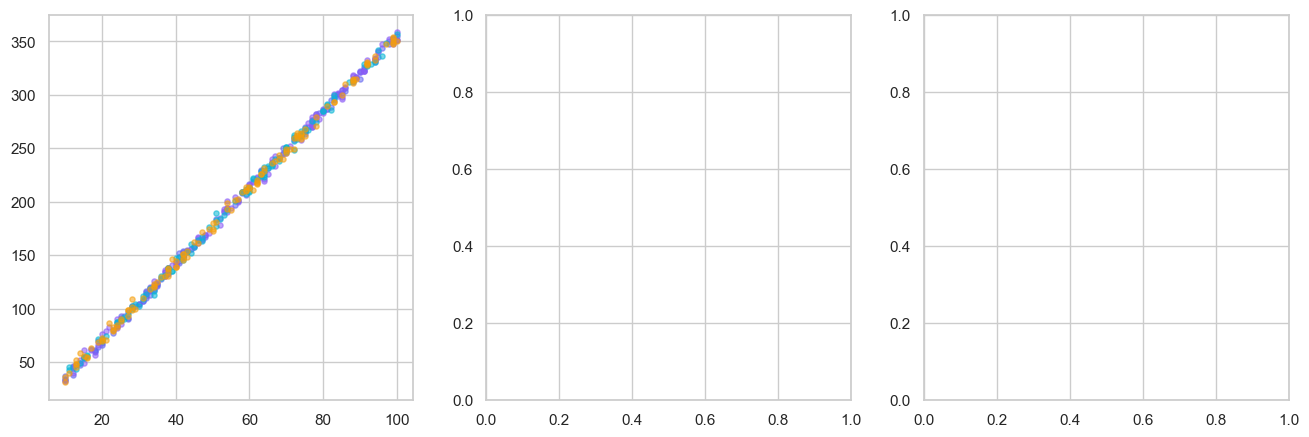

In [13]:
# Scatter plots: TV, Radio, Social Media vs Sales — 500 samples, coloured by influencer tier
samp = df.sample(min(500, len(df)), random_state=42)
channels = ["TV", "Radio", "Social Media"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ch in zip(axes, channels):
    for inf in INF_ORDER:
        sub = samp[samp["Influencer"] == inf]
        mask_nz = sub[ch] > 0
        ax.scatter(sub.loc[mask_nz, ch], sub.loc[mask_nz, TARGET_REG],
                   alpha=0.55, s=14, color=INF_COLOR[inf], label=inf)
    # regression line over full sample
    m, b = np.polyfit(samp[ch], samp[TARGET_REG], 1)
    x_line = np.linspace(samp[ch].min(), samp[ch].max(), 100)
    ax.plot(x_line, m * x_line + b, color=CH[ch], linewidth=2.5, linestyle="--")
    r = corr.loc[ch, TARGET_REG]
    ax.set_xlabel(f"{ch} Budget (M)", fontsize=11)
    ax.set_ylabel("Sales (M)", fontsize=11)
    ax.set_title(f"{ch} vs Sales\nr = {r:.4f}", fontsize=12, pad=8)
    ax.legend(fontsize=8, loc="lower right", markerscale=1.5)
    ax.grid(alpha=0.25)

plt.suptitle("Channel Budgets vs Sales — scatter + regression line (500 random samples)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 11. Key Findings

Summary aligned with dashboard insights — values computed from this notebook's analysis.

In [ ]:
best_channel = max(correlations, key=correlations.get)
best_r = correlations[best_channel]
top_inf = mean_sales.idxmax()
bottom_inf = mean_sales.idxmin()

findings = [
    ("Strongest predictor", f"{best_channel} has the highest Pearson correlation with Sales (r = {best_r:.4f})"),
    ("Influencer effect", f"{top_inf} influencers yield highest mean sales ({mean_sales[top_inf]:.2f}M); {bottom_inf} the lowest ({mean_sales[bottom_inf]:.2f}M)"),
    ("Budget spread", f"TV dominates budget allocation ({tv_budget_pct}% of avg channel spend); Social Media is smallest"),
    ("Class balance", f"Quantile-based split yields ~equal Low / Medium / High classes ({counts.min()}–{counts.max()} campaigns each)"),
    ("Outliers (IQR)", f"{total_outliers} total outliers across all features" + (" — dataset is clean" if total_outliers == 0 else "")),
    ("Missing values", f"{df.isnull().sum().sum()} missing cells — median/mode imputation sufficient"),
    ("Avg ROI", f"Mean ROI = {df['ROI'].mean():.4f} across {len(df):,} campaigns"),
]

findings_df = pd.DataFrame(findings, columns=["Finding", "Detail"])
display(findings_df)

print("\nThese findings motivate our preprocessing (StandardScaler, median imputation)")
print("and confirm that tree-based models should capture non-linear channel interactions.")